Part C

Question 21.

In [2]:
import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA available: True
GPU: NVIDIA GeForce RTX 3060


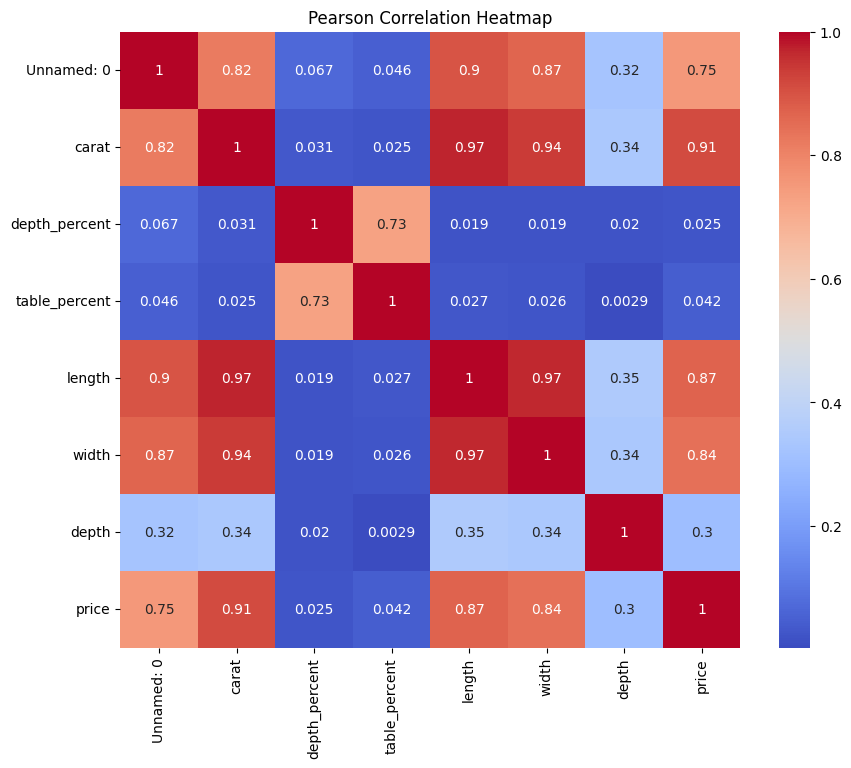

Correlation with price:
price            1.000000
carat            0.913479
length           0.869521
width            0.841887
Unnamed: 0       0.753482
depth            0.299696
table_percent    0.042453
depth_percent    0.025469
Name: price, dtype: float64


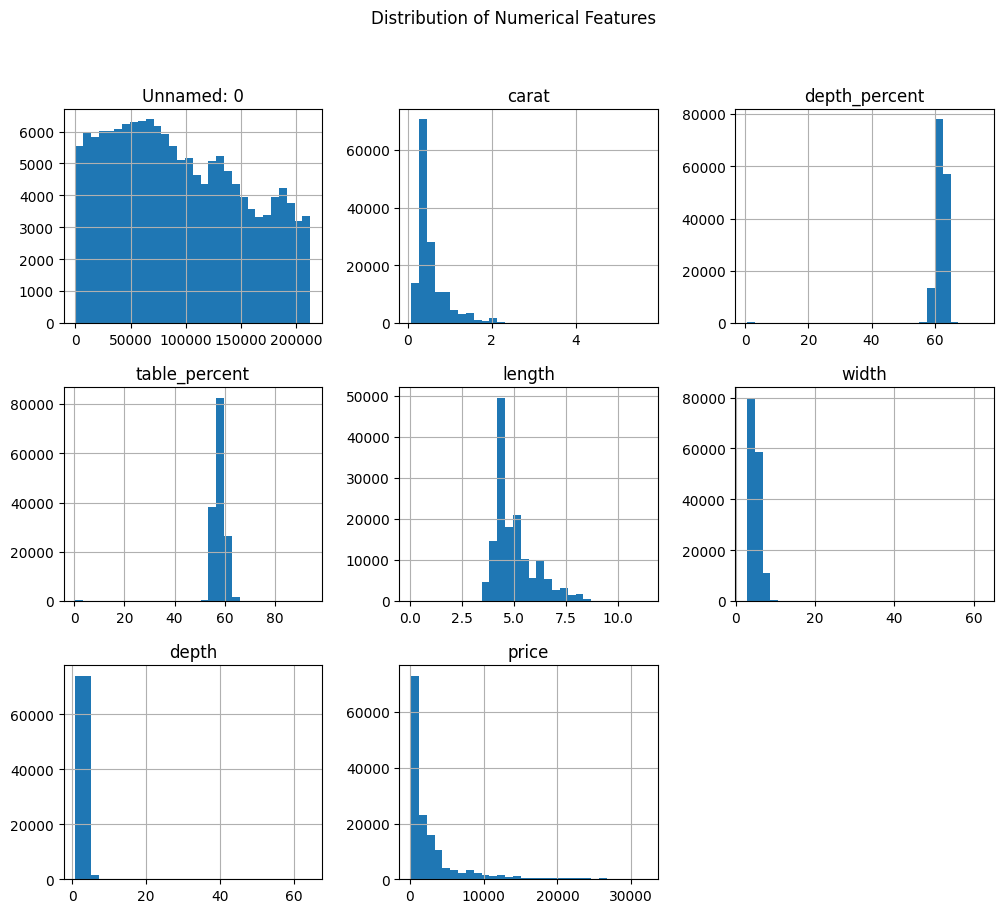

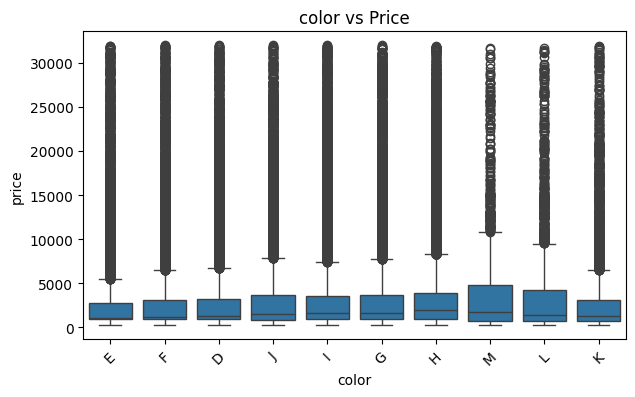

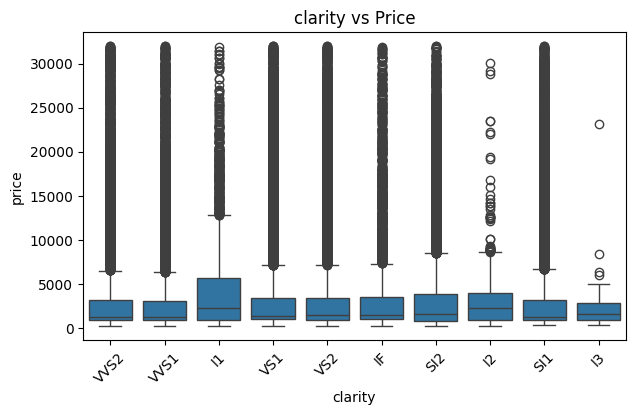

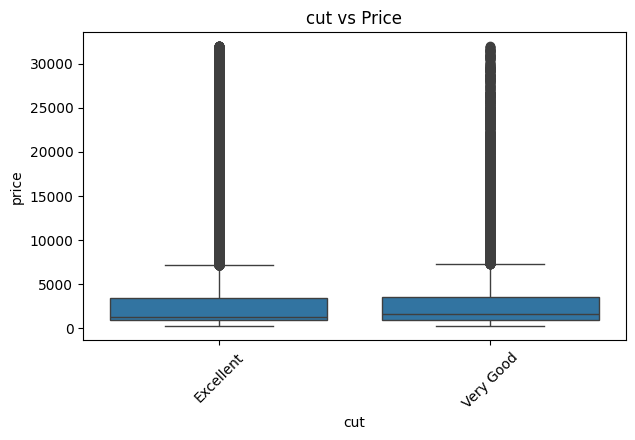

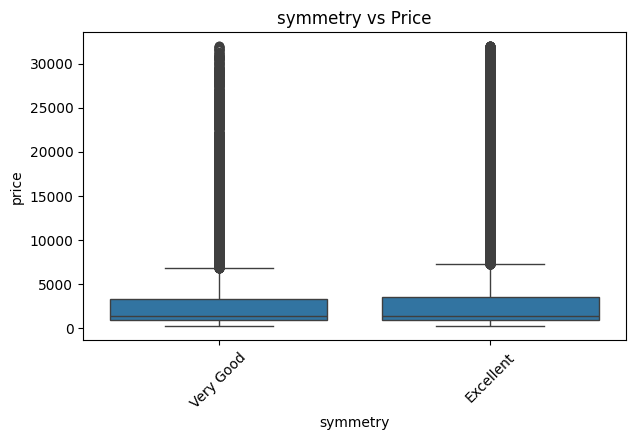

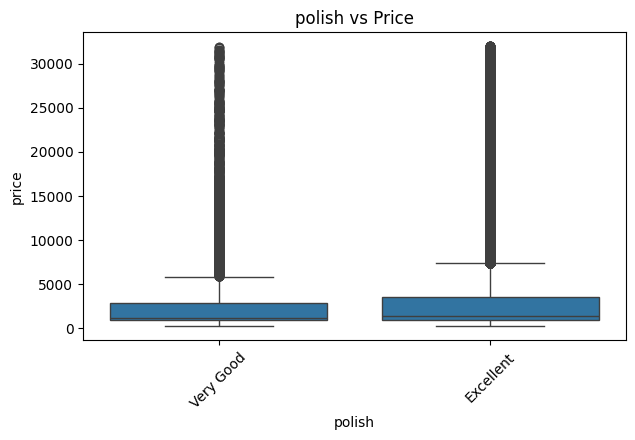

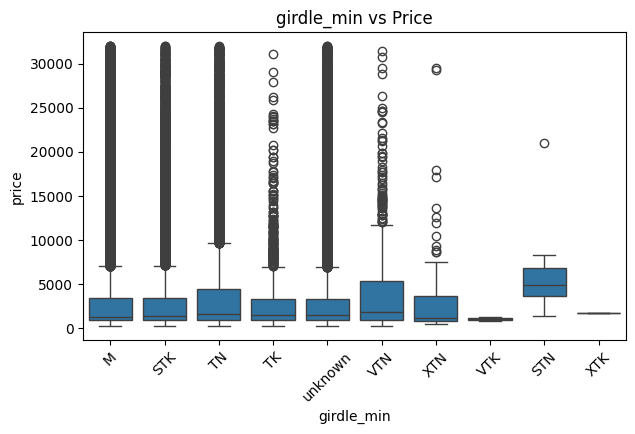

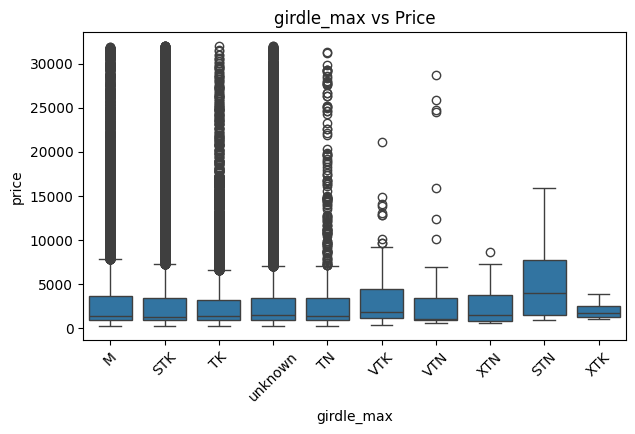

In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

diamonds_df = pd.read_csv("datasets/diamonds_ece219.csv")

numeric_features = diamonds_df.select_dtypes(include=["int64", "float64"])
correlation_matrix = numeric_features.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, cmap="coolwarm", annot=True)
plt.title("Pearson Correlation Heatmap")
plt.show()

price_correlation = correlation_matrix["price"].abs().sort_values(ascending=False)
print("Correlation with price:")
print(price_correlation)

numeric_features.hist(figsize=(12,10), bins=30)
plt.suptitle("Distribution of Numerical Features")
plt.show()

categorical_features = diamonds_df.select_dtypes(include="object").columns

for feature in categorical_features:
    plt.figure(figsize=(7,4))
    sns.boxplot(x=diamonds_df[feature], y=diamonds_df["price"])
    plt.title(f"{feature} vs Price")
    plt.xticks(rotation=45)
    plt.show()

1. Highest Absolute Correlation with Price

The features with the highest absolute correlation with price are carat (0.91), length (0.87), and width (0.84). The correlation patterns suggest the price is mainly related to the size of the diamond. Larger ones cost more.

2. Features with High Skewness

The carat, width, depth, and price distributions are show high right-skewness. A simple preprocessing step to remove this is by applying a log transformation like log(carat), to make it a little more balanced. 

3. Trends in Categorical Features

Significant trends is that diamonds with higher quality characteristics tend to have higher prices. Great cuts, clarity, and color all show signs of higher quality and higher prices.

Question 22.

In [ ]:
from sklearn.preprocessing import OneHotEncoder

# scalar encodind
quality_maps = {
    "cut": {"Very Good": 1, "Excellent": 2},
    "symmetry": {"Very Good": 1, "Excellent": 2},
    "polish": {"Very Good": 1, "Excellent": 2}
}

diamonds_encoded = diamonds_df.copy()

for feature, mapping in quality_maps.items():
    diamonds_encoded[feature] = diamonds_encoded[feature].map(mapping)

# one-hot encoding
diamonds_encoded = pd.get_dummies(
    diamonds_encoded,
    columns=["color", "clarity", "girdle_min", "girdle_max"],
    drop_first=True
)

print(diamonds_encoded.head())

   Unnamed: 0  carat  cut  symmetry  polish  depth_percent  table_percent  \
0           0   0.09    2         1       1           62.7           59.0   
1           1   0.09    1         1       1           61.9           59.0   
2           2   0.09    2         1       1           61.1           59.0   
3           3   0.09    2         1       1           62.0           59.0   
4           4   0.09    1         1       2           64.9           58.5   

   length  width  depth  ...  girdle_min_unknown  girdle_max_STK  \
0    2.85   2.87   1.79  ...               False           False   
1    2.84   2.89   1.78  ...               False            True   
2    2.88   2.90   1.77  ...               False           False   
3    2.86   2.88   1.78  ...               False            True   
4    2.79   2.83   1.82  ...               False            True   

   girdle_max_STN  girdle_max_TK  girdle_max_TN  girdle_max_VTK  \
0           False          False          False           Fal

The categorical features in the dataset are cut, color, clarity, symmetry, polish, girdle_min, and girdle_max.

cut, symmetry, polish were encoded using scalar encoding because these categories represent an ordered quality ranking

color and clarity were encoded using one-hot encoding because the categories represent labels rather than a strictly numeric progression

girdle_min and girdle_max were also encoded using one-hot encoding because their categories represent types

– What information does one-hot encoding discard?
One-hot encoding discards any ordering or ranking information between categories

– What assumption should hold strongly if we perform the scalar encoding instead?
It assumes the categories have a meaningful ordinal relationship

Question 23.

In [7]:
from sklearn.preprocessing import StandardScaler

features = diamonds_encoded.drop(columns=["price"])
target = diamonds_encoded["price"]
scaler = StandardScaler()
features_standardized = scaler.fit_transform(features)
features_standardized_df = pd.DataFrame(features_standardized, columns=features.columns)
diamonds_standardized = pd.concat([features_standardized_df, target.reset_index(drop=True)], axis=1)
diamonds_standardized.to_csv("datasets/diamonds_standardized.csv", index=False)

Question 24.

In [ ]:
from sklearn.feature_selection import mutual_info_regression, f_regression
import pandas as pd

df = pd.read_csv("datasets/diamonds_standardized.csv")
df = df.drop(columns=["Unnamed: 0"])
X = df.drop(columns=["price"])
y = df["price"]

mi_scores = mutual_info_regression(X, y, random_state=42)
mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

print("Top 5 features using Mutual Information:")
print(mi_series.head(5))

f_scores, _ = f_regression(X, y)
f_series = pd.Series(f_scores, index=X.columns).sort_values(ascending=False)

print("\nTop 5 features using F Regression:")
print(f_series.head(5))

selected_features = list(set(mi_series.head(5).index).union(set(f_series.head(5).index)))

selected_df = df[selected_features + ["price"]]
selected_df.to_csv("datasets/diamonds_selected.csv", index=False)

Top 5 features using Mutual Information:
carat          1.373192
width          1.205328
length         1.192119
depth          1.158406
clarity_SI2    0.046802
dtype: float64

Top 5 features using F Regression:
carat     755380.195809
length    464517.682462
width     364744.610195
depth      14789.226399
polish       453.535242
dtype: float64


Question 25.

In [10]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.model_selection import cross_validate, GridSearchCV
import numpy as np
import pandas as pd

df = pd.read_csv("datasets/diamonds_selected.csv")

X = df.drop(columns=["price"])
y = df["price"]

# Ordinary Least Squares
ols = LinearRegression()
ols_scores = cross_validate(
    ols, X, y,
    cv=10,
    scoring="neg_root_mean_squared_error",
    return_train_score=True
)

print("OLS Train RMSE:", -np.mean(ols_scores["train_score"]))
print("OLS Validation RMSE:", -np.mean(ols_scores["test_score"]))

# Lasso Regression
lasso = Lasso(max_iter=10000)
lasso_params = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
lasso_search = GridSearchCV(
    lasso,
    lasso_params,
    cv=10,
    scoring="neg_root_mean_squared_error"
)
lasso_search.fit(X, y)

print("\nBest Lasso alpha:", lasso_search.best_params_)
print("Lasso RMSE:", -lasso_search.best_score_)

# Ridge Regression
ridge = Ridge()
ridge_params = {"alpha": [0.001, 0.01, 0.1, 1, 10]}
ridge_search = GridSearchCV(
    ridge,
    ridge_params,
    cv=10,
    scoring="neg_root_mean_squared_error"
)
ridge_search.fit(X, y)

print("\nBest Ridge alpha:", ridge_search.best_params_)
print("Ridge RMSE:", -ridge_search.best_score_)

OLS Train RMSE: 1792.0578576527682
OLS Validation RMSE: 1575.3447536834963

Best Lasso alpha: {'alpha': 0.001}
Lasso RMSE: 1575.3563180562553

Best Ridge alpha: {'alpha': 0.001}
Ridge RMSE: 1575.3449367313988


The objective function of linear regression is to minimize the sum of squared errors between predicted 
and actual values.

• Explain how each regularization scheme affects the learned parameter set.
OLS: Minimizes squared error with no regularization
Lasso (L1): Adds a penalty on the absolute value of coefficients, which can shrink some coefficients to zero
Ridge (L2): Adds a penalty on the squared coefficients, shrinking them toward zero but keeping all features

• Report your choice of the best regularization scheme along with the optimal penalty parameter
and explain how you (or your agent) computed it
The best model is Ridge regression with alpha = 0.001, since it achieved the lowest RMSE (~1575.34) in 10-fold cross-validation. The optimal alpha was found using GridSearchCV

• Some linear regression packages return p-values for different features. What is the meaning
of these p-values and how can you infer the most significant features? A qualitative reasoning
is sufficient.
The meaning of these p-values is that is shows the statistical significance of these features, where smaller p-values are more likely to have a meaningful relationship with target features.